In [1]:
import numpy as np
from pyrocko import moment_tensor as mtm
from importlib import reload
import matplotlib.pyplot as plt
from matplotlib import ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from tqdm import tqdm

import sys
sys.path.append('./Venus_Detectability/')

import proba_modules as pm
import VCD_trajectory_modules as VCD
import proba_volcanoes_modules as pvm

In [41]:
reload(VCD)
reload(pvm)

def compute_latfinals(alts_balloon):
    
    dir_data = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/'
    #alt_balloon = 60.
    
    R0 = 6371000  # Earth's radius in meters
    lat_vol, lon_vol = 0, 0.
    lat_offset, lon_offset = np.linspace(-70., 70., 40), np.linspace(-90., 90., 20)
    mission_duration = (2./12.)*365*24*3600
    dt = 1*3600/6.

    LAT_offset, LON_offset = np.meshgrid(lat_offset, lon_offset)
    LAT_offset_shape_init = LAT_offset.shape
    LAT_offset, LON_offset = LAT_offset.ravel(), LON_offset.ravel()
    lat0 = lat_vol+LAT_offset  # Initial latitude in degrees
    lon0 = lon_vol+LON_offset  # Initial longitude in degrees

    times = np.arange(0, mission_duration, dt) 
    TIMES, ID_LAT0 = np.meshgrid(times, np.arange(LAT_offset.size))
    shape_TIMES = TIMES.shape # balloon init loc/t0 x balloon flight time 
    TIMES, ID_LAT0 = TIMES.ravel(), ID_LAT0.ravel() 

    dt_new = dt
    idx_dt_step = int(dt_new/dt)
    times_downsampled = times[::idx_dt_step]

    latmaxs, lonmaxs = np.zeros(LAT_offset_shape_init+(len(alts_balloon),)), np.zeros(LAT_offset_shape_init+(len(alts_balloon),))
    print('latmaxs', latmaxs.shape, LAT_offset_shape_init)
    for ialt, alt_balloon in enumerate(alts_balloon):
    
        file_atmos = f'{dir_data}VCD_atmos_globe_new.dat'
        winds = VCD.get_winds(file_atmos, alt_balloon*1e3)
        wind_direction_interpolator, wind_strength_interpolator, _ = VCD.get_winds_interpolator(file_atmos, alt_balloon*1e3, winds=winds)
        latitudes, longitudes = pvm.compute_positions_vectorized_w_interpolator(lat0[ID_LAT0].reshape(shape_TIMES), lon0[ID_LAT0].reshape(shape_TIMES), wind_direction_interpolator, wind_strength_interpolator, TIMES.reshape(shape_TIMES), R0)
        latitudes, longitudes = latitudes.reshape(shape_TIMES)[:,::idx_dt_step], longitudes.reshape(shape_TIMES)[:,::idx_dt_step]
 
        latmaxs[:,:,ialt] = latitudes[:,-1].reshape(LAT_offset_shape_init)
        #latmax_q = np.quantile(latmax, q=0.5, axis=0)
        #latmax_std = np.std(latmax, axis=0)
        lonmaxs[:,:,ialt] = longitudes[:,-1].reshape(LAT_offset_shape_init)
    
    return latmaxs, lonmaxs, lat_offset, lon_offset

alts_balloon = [50, 55, 60]
latmaxs, lonmaxs, lat_offset, lon_offset = compute_latfinals(alts_balloon)

latmaxs (20, 40, 3) (20, 40)


./Venus_Detectability/VCD_trajectory_modules.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['gid'] = winds.groupby(['lat', 'lon'])['val'].transform('idxmin')
./Venus_Detectability/VCD_trajectory_modules.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winds['wind_strength'] = winds.groupby(['lat', 'lon'])['val'].transform(lambda x: np.sqrt(sum(x**2)))
./Venus_Detectability/VCD_trajectory_modules.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

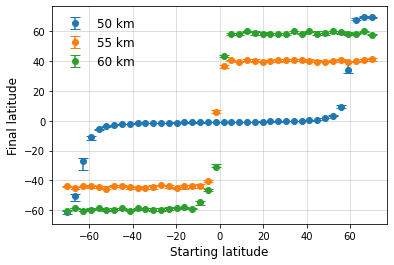

In [52]:
plt.figure()

for ialt, alt in enumerate(alts_balloon):
    latmax_q = np.quantile(latmaxs[:,:,ialt], q=0.5, axis=0)
    latmax_qmin = np.quantile(latmaxs[:,:,ialt], q=0.1, axis=0)
    latmax_qmax = np.quantile(latmaxs[:,:,ialt], q=0.9, axis=0)

    plt.errorbar(lat_offset, latmax_q, yerr=[latmax_q-latmax_qmin, latmax_qmax-latmax_q], fmt='o', capsize=5, label=f'{alt:.0f} km')

plt.xlabel('Starting latitude', fontsize=12.)
plt.ylabel('Final latitude', fontsize=12.)
plt.legend(frameon=False, fontsize=12.)
plt.grid(alpha=0.5)
plt.savefig('./figures/sensitivity_latitude_trajectory.pdf')